In [3]:
import pandas as pd


In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
from sklearn.metrics import mean_absolute_error

In [8]:
df = pd.read_csv("superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df = df[['Order Date', 'Sales']]
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')
df.head()

,Order Date,Sales
7980,2014-01-03,16.448
739,2014-01-04,11.784
740,2014-01-04,272.736
741,2014-01-04,3.540
1759,2014-01-05,19.536


In [10]:
df = df.groupby('Order Date')['Sales'].sum().reset_index()
df.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [11]:
df['Day'] = df['Order Date'].dt.day
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df.head()

,Order Date,Sales,Day,Month,Year
0,2014-01-03,16.448,3,1,2014
1,2014-01-04,288.060,4,1,2014
2,2014-01-05,19.536,5,1,2014
3,2014-01-06,4407.100,6,1,2014
4,2014-01-07,87.158,7,1,2014


In [12]:
X = df[['Day','Month','Year']]
y = df['Sales']

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:


future_dates = pd.date_range(start=df['Order Date'].max(), periods=30)

future_df = pd.DataFrame()
future_df['Order Date'] = future_dates
future_df['Day'] = future_df['Order Date'].dt.day
future_df['Month'] = future_df['Order Date'].dt.month
future_df['Year'] = future_df['Order Date'].dt.year

future_df['Predicted_Sales'] = model.predict(future_df[['Day','Month','Year']])
future_df.head()

,Order Date,Day,Month,Year,Predicted_Sales
0,2017-12-30,30,12,2017,2985.179867
1,2017-12-31,31,12,2017,2979.278331
2,2018-01-01,1,1,2018,1589.195035
3,2018-01-02,2,1,2018,1583.293500
4,2018-01-03,3,1,2018,1577.391964


In [16]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X)
print("MAE:", mean_absolute_error(y, y_pred))

MAE: 1464.913212647868


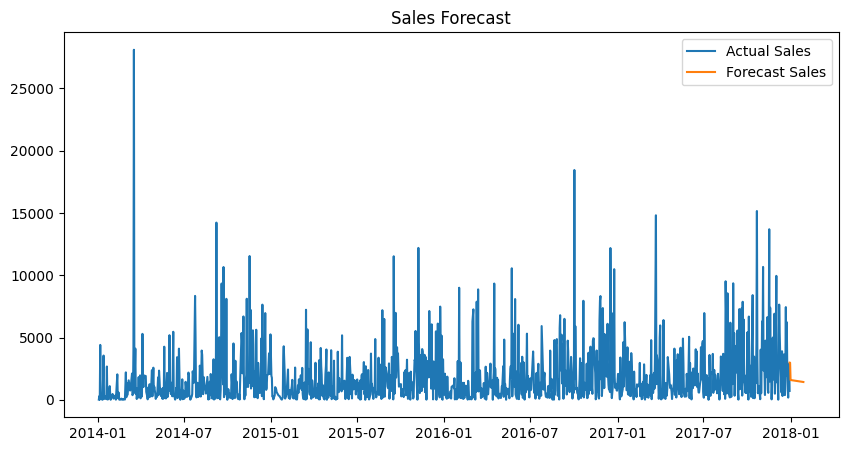

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Order Date'], df['Sales'], label="Actual Sales")
plt.plot(future_df['Order Date'], future_df['Predicted_Sales'], label="Forecast Sales")
plt.legend()
plt.title("Sales Forecast")
plt.show()